# 6. Spatially Correlated Noise in the Stochastic Heat Equation

In Notebook 5, we constructed spatially correlated Gaussian noise with a prescribed covariance structure.

In this notebook, we use this noise to drive the stochastic heat equation and compare the resulting solutions with those driven by space-time white noise.

## Objectives

In this notebook we will

- incorporate spatially correlated Gaussian noise into the stochastic heat equation,
- compare solutions driven by white and spatially correlated noise, and
- investigate the effect of the correlation length on the solution.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Spatial grid
N = 100
h = 1 / N
x = np.arange(N) * h

# Model parameters
kappa = 0.5
sigma = 1.0

# Time discretization
dt = 0.2 * h**2
T = 0.05
num_steps = int(T / dt)

# Output
record_every = 10

# Initial condition
u0 = np.ones(N)

## Mathematical Background

We consider the stochastic heat equation

$$
du(t,x)
=
\kappa \Delta u(t,x)\,dt
+
\sigma u(t,x)\,dW(t,x),
$$

on the one-dimensional periodic domain.

The spatial covariance of the noise is prescribed by

$$
Q(x,y)
=
\exp\left(
-\frac{d(x,y)}{\ell}
\right),
$$

where $d(x,y)$ is the periodic distance and $\ell>0$ is the correlation length.

The white-noise case provides a baseline for comparison with spatially correlated noise.

In [3]:
def laplacian(u, h):
    """Compute the one-dimensional periodic discrete Laplacian."""
    return (np.roll(u, -1) - 2 * u + np.roll(u, 1)) / h**2

In [4]:
def covariance_matrix(x, ell):
    """
    Construct the exponential covariance matrix
    on a one-dimensional periodic domain.
    """
    N = len(x)
    h = x[1] - x[0]
    domain_length = N * h

    Q = np.zeros((N, N))

    for i in range(N):
        for j in range(N):
            distance = abs(x[i] - x[j])
            periodic_distance = min(
                distance,
                domain_length - distance,
            )

            Q[i, j] = np.exp(
                -periodic_distance / ell
            )

    return Q

## Numerical Method

The deterministic diffusion term is approximated using the periodic discrete Laplacian. The stochastic term is advanced using the same Euler--Maruyama discretization as in the white-noise case.

For spatially correlated noise, a standard Gaussian vector $Z^n$ is transformed using the Cholesky factor $L$ of the covariance matrix:

$$
Q = LL^\top,
\qquad
\xi^n = LZ^n.
$$

The numerical update is

$$
u_i^{n+1}
=
u_i^n
+
\kappa \Delta_h u_i^n\,\Delta t
+
\sigma u_i^n
\sqrt{\frac{\Delta t}{h}}\,
\xi_i^n.
$$

Setting $L=None$ recovers the spatially independent white-noise simulation.

In [5]:
def solve_correlated_stochastic_heat_equation(
    u0,
    h,
    dt,
    num_steps,
    kappa=0.5,
    sigma=1.0,
    L=None,
    record_every=100,
    rng=None,
):
    """
    Solve the one-dimensional stochastic heat equation
    with either white or spatially correlated noise.
    """
    if rng is None:
        rng = np.random.default_rng()

    u = u0.copy()

    snapshots = [u.copy()]
    times = [0.0]

    for n in range(num_steps):
        z = rng.normal(size=u.size)

        if L is None:
            noise_sample = z
        else:
            noise_sample = L @ z

        dW = sigma * np.sqrt(dt / h) * noise_sample

        diffusion = kappa * dt * laplacian(u, h)
        stochastic_term = u * dW

        u += diffusion + stochastic_term

        if (n + 1) % record_every == 0:
            snapshots.append(u.copy())
            times.append((n + 1) * dt)

    return {
        "solution": u,
        "snapshots": snapshots,
        "times": times,
    }

## Numerical Experiments

### White Noise and Spatially Correlated Noise

We first compare solutions driven by white noise and spatially correlated noise with correlation length

$$
\ell=0.05.
$$

The same underlying Gaussian sequence is used in both simulations.

Spatial correlation changes the spatial structure of the solution by introducing dependence between neighboring locations.

In [6]:
ell = 0.05

Q = covariance_matrix(x, ell)
L = np.linalg.cholesky(Q)

In [7]:
seed = 42

white_result = solve_correlated_stochastic_heat_equation(
    u0,
    h,
    dt,
    num_steps,
    kappa=kappa,
    sigma=sigma,
    L=None,
    record_every=record_every,
    rng=np.random.default_rng(seed),
)

colored_result = solve_correlated_stochastic_heat_equation(
    u0,
    h,
    dt,
    num_steps,
    kappa=kappa,
    sigma=sigma,
    L=L,
    record_every=record_every,
    rng=np.random.default_rng(seed),
)

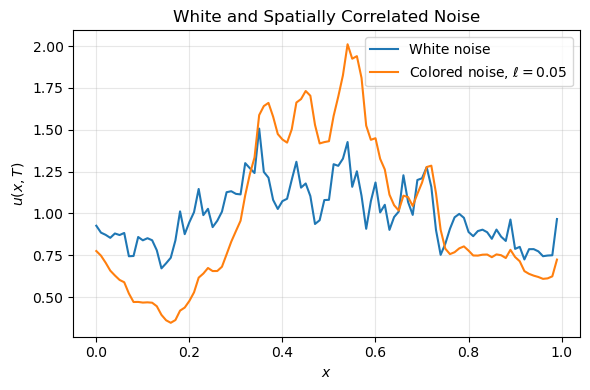

In [8]:
plt.figure(figsize=(6, 4))

plt.plot(
    x,
    white_result["solution"],
    label="White noise",
)

plt.plot(
    x,
    colored_result["solution"],
    label=rf"Colored noise, $\ell={ell}$",
)

plt.xlabel(r"$x$")
plt.ylabel(r"$u(x,T)$")
plt.title("White and Spatially Correlated Noise")

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Influence of the Correlation Length

We compare the white-noise solution with colored-noise solutions for

$$
\ell \in \{0.01,\,0.05,\,0.20\}.
$$

The same underlying Gaussian sequence is used for each simulation so that the correlation length is the only changing noise parameter.

Increasing the correlation length extends the range of spatial dependence and changes the spatial variation of the solution.

In [9]:
ells = [0.01, 0.05, 0.20]

In [10]:
cholesky_factors = {
    ell: np.linalg.cholesky(
        covariance_matrix(x, ell)
    )
    for ell in ells
}

In [11]:
colored_results = {}

for ell_value in ells:
    colored_results[ell_value] = (
        solve_correlated_stochastic_heat_equation(
            u0,
            h,
            dt,
            num_steps,
            kappa=kappa,
            sigma=sigma,
            L=cholesky_factors[ell_value],
            record_every=record_every,
            rng=np.random.default_rng(seed),
        )
    )

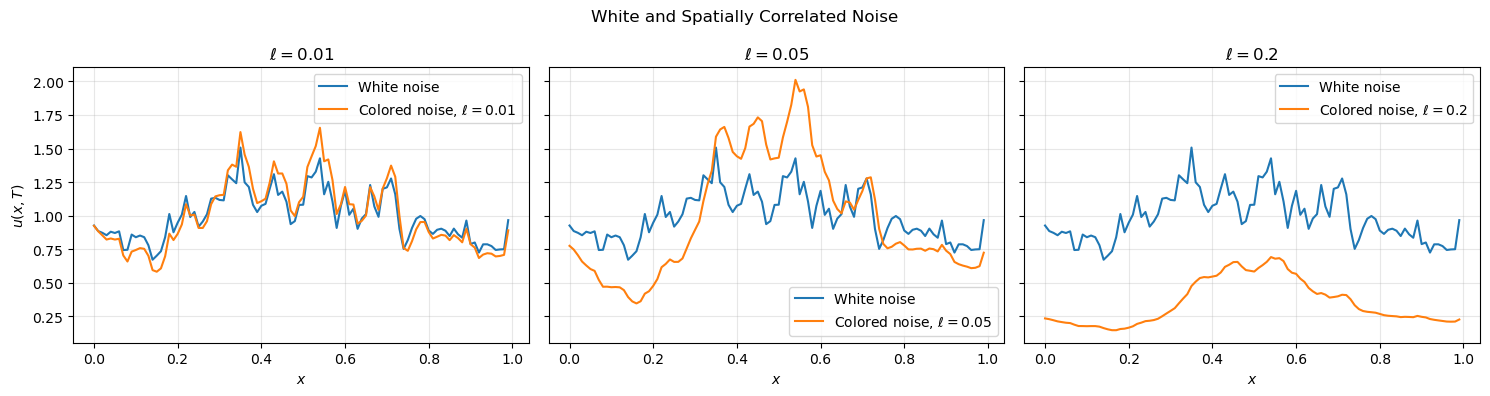

In [12]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 4),
    sharey=True,
)

for ax, ell_value in zip(axes, ells):
    ax.plot(
        x,
        white_result["solution"],
        label="White noise",
    )

    ax.plot(
        x,
        colored_results[ell_value]["solution"],
        label=rf"Colored noise, $\ell={ell_value}$",
    )

    ax.set_title(rf"$\ell={ell_value}$")
    ax.set_xlabel(r"$x$")
    ax.grid(alpha=0.3)
    ax.legend()

axes[0].set_ylabel(r"$u(x,T)$")

fig.suptitle(
    "White and Spatially Correlated Noise"
)

plt.tight_layout()
plt.show()

## Summary

In this notebook, we extended the stochastic heat equation simulation from spatially independent white noise to spatially correlated Gaussian noise.

Using matched Gaussian sequences, we compared white and colored noise and examined how the correlation length affects the spatial structure of the solution.

In the next notebook, we will use Monte Carlo simulation to study the moments of the stochastic heat equation under spatially correlated noise.